In [11]:
import util
from models import EEGNet

from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint
from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from tensorflow.keras import utils as np_utils
from pyriemann.utils.viz import plot_confusion_matrix

In [12]:
#training_files = ["A01T", "A02T", "A03T","A04T", "A05T", "A06T", "A07T", "A08T", "A09T"]
#test_files = ["A01E", "A02E", "A03E", "A04E", "A05E", "A06E", "A07E", "A08E", "A09E"]

training_files = ["A01T"]
test_files = ["A01E"]

tmin, tmax = 0.5, 2.5 # seconds before and after stimulus we want to record 

amplitude_magnification = 1000 #current best = 1000

X_train_original, Y_train_original, X_test_original, Y_test, chans, kernels, samples, names = util.get_bci_2a(
    training_files, test_files,
    bandpass = [4,40],
    tmin = tmin, tmax = tmax,
    mode = "gdf",
    amp_mag= amplitude_magnification #ALSO ADD BASELINE
    )

Extracting EDF parameters from /Users/bobbeashel/Desktop/CITS4010/Project/data/BCICIV_2a_gdf/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['769', '770', '771', '772']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped
Extracting EDF parameters from /Users/bobbeashel/Desktop/CITS4010/Project/data/BCICIV_2a_gdf/A01E.gdf...
GDF file detected
Setting channel info structure...
Could not determ

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:115: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.
/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['783']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:115: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.


In [13]:
# take 50/25/25 percent of the data to train/validate/test
#X_train, X_temp, Y_train, Y_temp = train_test_split(X_test, Y_test, test_size=0.5, stratify=Y_train)
#X_validate, X_test, Y_validate, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, stratify=Y_temp)


X_train, X_validate, Y_train, Y_validate = train_test_split(X_train_original, Y_train_original, test_size=0.2, stratify=Y_train_original)

X_train      = X_train.reshape(X_train.shape[0], chans, samples, kernels)
X_validate   = X_validate.reshape(X_validate.shape[0], chans, samples, kernels)
X_test       = X_test_original.reshape(X_test_original.shape[0], chans, samples, kernels)

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

Y_train = np_utils.to_categorical(Y_train) # One hot encoding format for probabilistic classification
Y_validate = np_utils.to_categorical(Y_validate) # One hot encoding format for probabilistic classification
Y_test = np_utils.to_categorical(Y_test) # One hot encoding format for probabilistic classification

# 2) Standardize per-channel (over time & trials)
mean  = X_train.mean(axis = (0,2), keepdims=True)
std   = X_train.std(axis = (0,2), keepdims=True)
X_train    = (X_train   - mean) / std
X_validate = (X_validate- mean) / std
X_test     = (X_test    - mean) / std

# configure the EEGNet-8,2,16 model with kernel length of 32 samples (other 
# model configurations may do better, but this is a good starting point)
model = EEGNet(nb_classes = 4, Chans = chans, Samples = samples, 
               dropoutRate = 0.5, kernLength = 32, F1 = 8, D = 2, F2 = 16, 
               dropoutType = 'Dropout')

# compile the model and set the optimizers
model.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics = ['accuracy'])

numParams    = model.count_params()    

# set a valid path for your system to record model checkpoints
checkpointer = ModelCheckpoint(filepath='/tmp/checkpoint.h5', verbose=1, save_best_only=True)

###############################################################################
# if the classification task was imbalanced (significantly more trials in one
# class versus the others) you can assign a weight to each class during 
# optimization to balance it out. This data is approximately balanced so we 
# don't need to do this, but is shown here for illustration/completeness. 
###############################################################################

class_weights = {0:1, 1:1, 2:1, 3:1}

(230, 22, 500, 1) (288, 22, 500, 1)
(230,) (288,)


In [14]:
################################################################################
# fit the model. Due to very small sample sizes this can get
# pretty noisy run-to-run, but most runs should be comparable to xDAWN + 
# Riemannian geometry classification (below)
################################################################################
fittedModel = model.fit(X_train, Y_train, batch_size = 16, epochs = 300, 
                        verbose = 2, validation_data=(X_validate, Y_validate),
                        callbacks=[checkpointer])

Epoch 1/300

Epoch 1: val_loss improved from inf to 1.38626, saving model to /tmp/checkpoint.h5
15/15 - 1s - loss: 1.4147 - accuracy: 0.2652 - val_loss: 1.3863 - val_accuracy: 0.2586 - 551ms/epoch - 37ms/step
Epoch 2/300


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 1.38626 to 1.38624, saving model to /tmp/checkpoint.h5
15/15 - 0s - loss: 1.3745 - accuracy: 0.2913 - val_loss: 1.3862 - val_accuracy: 0.2414 - 270ms/epoch - 18ms/step
Epoch 3/300

Epoch 3: val_loss did not improve from 1.38624
15/15 - 0s - loss: 1.3636 - accuracy: 0.3391 - val_loss: 1.3864 - val_accuracy: 0.2069 - 261ms/epoch - 17ms/step
Epoch 4/300

Epoch 4: val_loss improved from 1.38624 to 1.38608, saving model to /tmp/checkpoint.h5
15/15 - 0s - loss: 1.3427 - accuracy: 0.3304 - val_loss: 1.3861 - val_accuracy: 0.1897 - 265ms/epoch - 18ms/step
Epoch 5/300

Epoch 5: val_loss improved from 1.38608 to 1.38448, saving model to /tmp/checkpoint.h5
15/15 - 0s - loss: 1.3173 - accuracy: 0.3870 - val_loss: 1.3845 - val_accuracy: 0.2414 - 269ms/epoch - 18ms/step
Epoch 6/300

Epoch 6: val_loss improved from 1.38448 to 1.37989, saving model to /tmp/checkpoint.h5
15/15 - 0s - loss: 1.2734 - accuracy: 0.4652 - val_loss: 1.3799 - val_accuracy: 0.2586 - 268ms/epoch

In [15]:
def accept_confident_probabilities(probs, k, Y_test):
    # Get indices of sorted probabilities (descending)
    sorted_indices = np.argsort(-probs, axis=1)

    # Highest and second-highest probabilities
    top1_probs = probs[np.arange(len(probs)), sorted_indices[:, 0]]
    top2_probs = probs[np.arange(len(probs)), sorted_indices[:, 1]]

    # Apply condition: only keep prediction if top1 >= 2 * top2
    preds = sorted_indices[:, 0]
    mask = top1_probs >= k * top2_probs
    print(len(mask))

    made_preds = preds[mask]
    Y_test_new = Y_test[mask]
    return made_preds, Y_test_new, mask

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 22, 500, 1)]      0         
                                                                 
 conv2d_2 (Conv2D)           (None, 22, 500, 8)        256       
                                                                 
 batch_normalization_6 (Bat  (None, 22, 500, 8)        32        
 chNormalization)                                                
                                                                 
 depthwise_conv2d_2 (Depthw  (None, 1, 500, 16)        352       
 iseConv2D)                                                      
                                                                 
 batch_normalization_7 (Bat  (None, 1, 500, 16)        64        
 chNormalization)                                                
                                                           

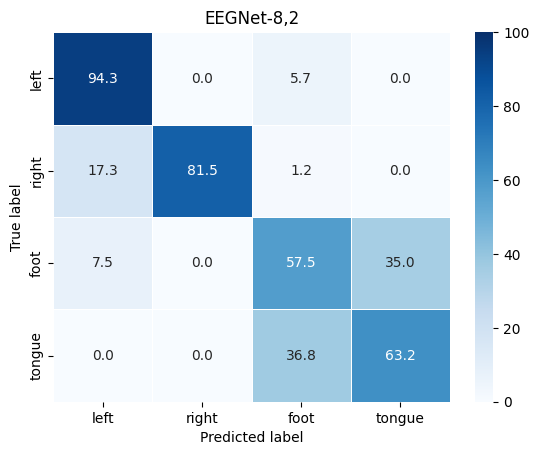

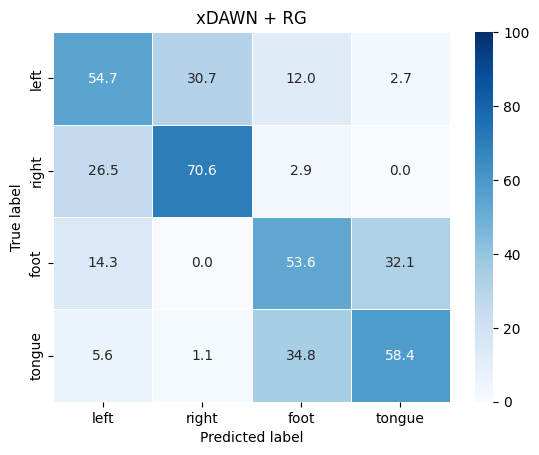

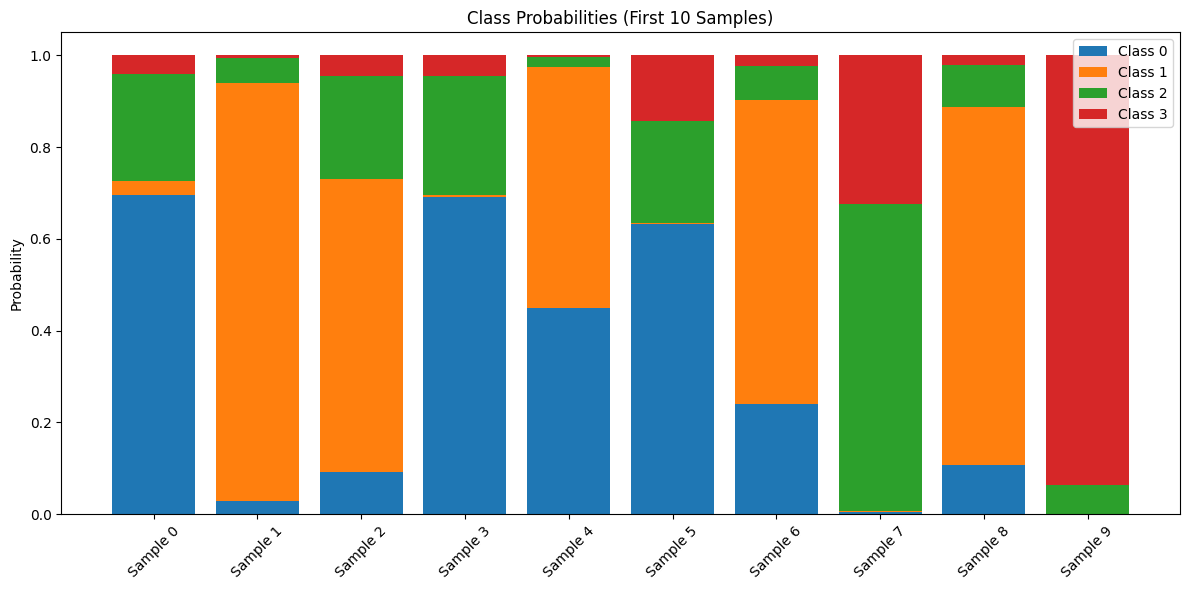

In [16]:
#########################################################################################################

# load optimal weights
model.load_weights('/tmp/checkpoint.h5')

#predict
print(model.summary())
probs = model.predict(X_test)

k=1.5 # If k is 1, just accept all highest probs (preds       = probs.argmax(axis = -1)  )
# k >= 1

preds, Y_test_eegnet, mask = accept_confident_probabilities(probs, k, Y_test)
omitted = X_test[~mask]

acc = np.mean(preds == Y_test_eegnet.argmax(axis=-1))
print("Classification accuracy EEGNet: %f " % (acc))
print(len(omitted), " samples deleted")

############################# xDAWN + RG Portion ##############################

# code is taken from PyRiemann's ERP sample script, which is decoding in 
# the tangent space with a logistic regression

n_components = 2  # pick some components

# set up sklearn pipeline
clf = make_pipeline(XdawnCovariances(n_components),
                    TangentSpace(metric='riemann'),
                    LogisticRegression())

preds_rg     = np.zeros(len(Y_test))

# reshape back to (trials, channels, samples)
X_train_reshaped      = X_train.reshape(X_train.shape[0], chans, samples)
X_test_reshaped       = X_test.reshape(X_test.shape[0], chans, samples)

# train a classifier with xDAWN spatial filtering + Riemannian Geometry (RG)
# labels need to be back in single-column format
clf.fit(X_train_reshaped, Y_train.argmax(axis = -1))
preds_rg     = clf.predict(X_test_reshaped)

# Printing the results
acc2         = np.mean(preds_rg == Y_test.argmax(axis = -1))
print("Classification accuracy xDAWN + RG: %f " % (acc2))

# plot the confusion matrices for both classifiers

plt.figure(0)
plot_confusion_matrix(preds, Y_test_eegnet.argmax(axis = -1), names, title = 'EEGNet-8,2')


plt.figure(1)
plot_confusion_matrix(preds_rg, Y_test.argmax(axis = -1), names, title = 'xDAWN + RG')

plt.show()

# Show only the first 10 samples for clarity
samples_to_plot = 10
util.plot_predicted_probs(probs, samples_to_plot)


In [17]:
# take 25/25/50 percent of the data to train/validate/test
#X_train, X_temp, Y_train, Y_temp = train_test_split(X_test, Y_test, test_size=0.5, stratify=Y_train)
#X_validate, X_test, Y_validate, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, stratify=Y_temp)

#X_test_original_reshaped = X_test_original.reshape(X_test_original.shape[0], chans, samples, kernels)
X_train = X_test_original[mask]
Y_train = Y_test[mask]


_, _, X_test, Y_test, chans, kernels, samples, names = util.get_bci_2a(
    None, test_files,
    bandpass = [4,40],
    tmin = tmin, tmax = tmax,
    mode = "gdf",
    amp_mag= amplitude_magnification #ALSO ADD BASELINE
    )

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

X_train, X_validate, Y_train, Y_validate = train_test_split(X_train, Y_train, test_size=0.2, stratify=Y_train)

X_train      = X_train.reshape(X_train.shape[0], chans, samples, kernels)
X_validate   = X_validate.reshape(X_validate.shape[0], chans, samples, kernels)
X_test       = X_test.reshape(X_test.shape[0], chans, samples, kernels)

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

#Y_train = np_utils.to_categorical(Y_train) # One hot encoding format for probabilistic classification #already been done
#Y_validate = np_utils.to_categorical(Y_validate) # One hot encoding format for probabilistic classification
Y_test = np_utils.to_categorical(Y_test) # One hot encoding format for probabilistic classification

# 2) Standardize per-channel (over time & trials)
mean  = X_train.mean(axis = (0,2), keepdims=True)
std   = X_train.std(axis = (0,2), keepdims=True)
X_train    = (X_train   - mean) / std
X_validate = (X_validate- mean) / std
X_test     = (X_test    - mean) / std

print('X_train shape:', X_train.shape)
print('y train shape', Y_train.shape)
print('X_test shape:', X_test.shape)
print('y test shape', Y_test.shape)
print('X_validation shape:', X_validate.shape)
print('y validation shape', Y_validate.shape)

###WHY IS THE Y TEST SHAPE INCORRECT 


# configure the EEGNet-8,2,16 model with kernel length of 32 samples (other 
# model configurations may do better, but this is a good starting point)
model = EEGNet(nb_classes = 4, Chans = chans, Samples = samples, 
               dropoutRate = 0.5, kernLength = 32, F1 = 8, D = 2, F2 = 16, 
               dropoutType = 'Dropout')

# compile the model and set the optimizers
model.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics = ['accuracy'])

numParams    = model.count_params()    

# set a valid path for your system to record model checkpoints
checkpointer = ModelCheckpoint(filepath='/tmp/checkpoint.h5', verbose=1, save_best_only=True)

###############################################################################
# if the classification task was imbalanced (significantly more trials in one
# class versus the others) you can assign a weight to each class during 
# optimization to balance it out. This data is approximately balanced so we 
# don't need to do this, but is shown here for illustration/completeness. 
###############################################################################

class_weights = {0:1, 1:1, 2:1, 3:1}

Extracting EDF parameters from /Users/bobbeashel/Desktop/CITS4010/Project/data/BCICIV_2a_gdf/A01E.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['783']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped
(224, 22, 500)
(224, 4)
(288, 22, 500)
(288,)
(179, 22, 500, 1) (288, 22, 500, 1)
(179, 4) (288,)
X_train shape: (179, 22, 500, 1)
y train shape (179, 4)
X_test shape: (288, 22, 500, 1)
y test s

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:115: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.


In [18]:
################################################################################
# fit the model. Due to very small sample sizes this can get
# pretty noisy run-to-run, but most runs should be comparable to xDAWN + 
# Riemannian geometry classification (below)
################################################################################
fittedModel = model.fit(X_train, Y_train, batch_size = 16, epochs = 300, 
                        verbose = 2, validation_data=(X_validate, Y_validate),
                        callbacks=[checkpointer])


Epoch 1/300

Epoch 1: val_loss improved from inf to 1.38573, saving model to /tmp/checkpoint.h5
12/12 - 0s - loss: 1.4259 - accuracy: 0.1955 - val_loss: 1.3857 - val_accuracy: 0.3111 - 485ms/epoch - 40ms/step
Epoch 2/300


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 1.38573 to 1.38516, saving model to /tmp/checkpoint.h5
12/12 - 0s - loss: 1.3810 - accuracy: 0.2737 - val_loss: 1.3852 - val_accuracy: 0.3333 - 214ms/epoch - 18ms/step
Epoch 3/300

Epoch 3: val_loss improved from 1.38516 to 1.38496, saving model to /tmp/checkpoint.h5
12/12 - 0s - loss: 1.3638 - accuracy: 0.3520 - val_loss: 1.3850 - val_accuracy: 0.2667 - 214ms/epoch - 18ms/step
Epoch 4/300

Epoch 4: val_loss improved from 1.38496 to 1.38481, saving model to /tmp/checkpoint.h5
12/12 - 0s - loss: 1.3526 - accuracy: 0.3855 - val_loss: 1.3848 - val_accuracy: 0.2667 - 215ms/epoch - 18ms/step
Epoch 5/300

Epoch 5: val_loss improved from 1.38481 to 1.38435, saving model to /tmp/checkpoint.h5
12/12 - 0s - loss: 1.3388 - accuracy: 0.3687 - val_loss: 1.3844 - val_accuracy: 0.2667 - 218ms/epoch - 18ms/step
Epoch 6/300

Epoch 6: val_loss improved from 1.38435 to 1.38348, saving model to /tmp/checkpoint.h5
12/12 - 0s - loss: 1.3255 - accuracy: 0.3911 - val_loss: 1.3

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 22, 500, 1)]      0         
                                                                 
 conv2d_3 (Conv2D)           (None, 22, 500, 8)        256       
                                                                 
 batch_normalization_9 (Bat  (None, 22, 500, 8)        32        
 chNormalization)                                                
                                                                 
 depthwise_conv2d_3 (Depthw  (None, 1, 500, 16)        352       
 iseConv2D)                                                      
                                                                 
 batch_normalization_10 (Ba  (None, 1, 500, 16)        64        
 tchNormalization)                                               
                                                           

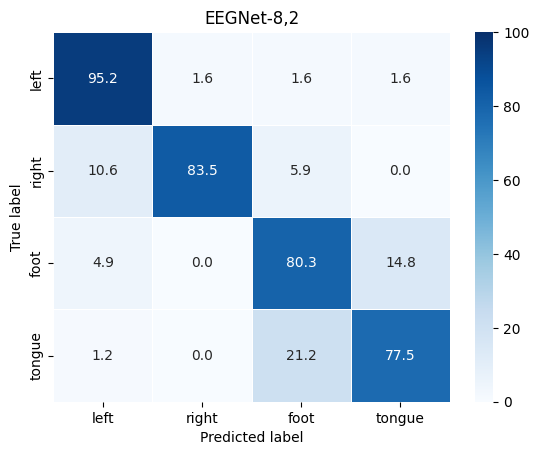

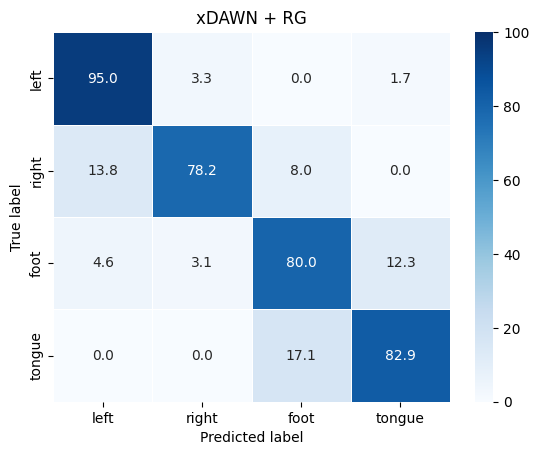

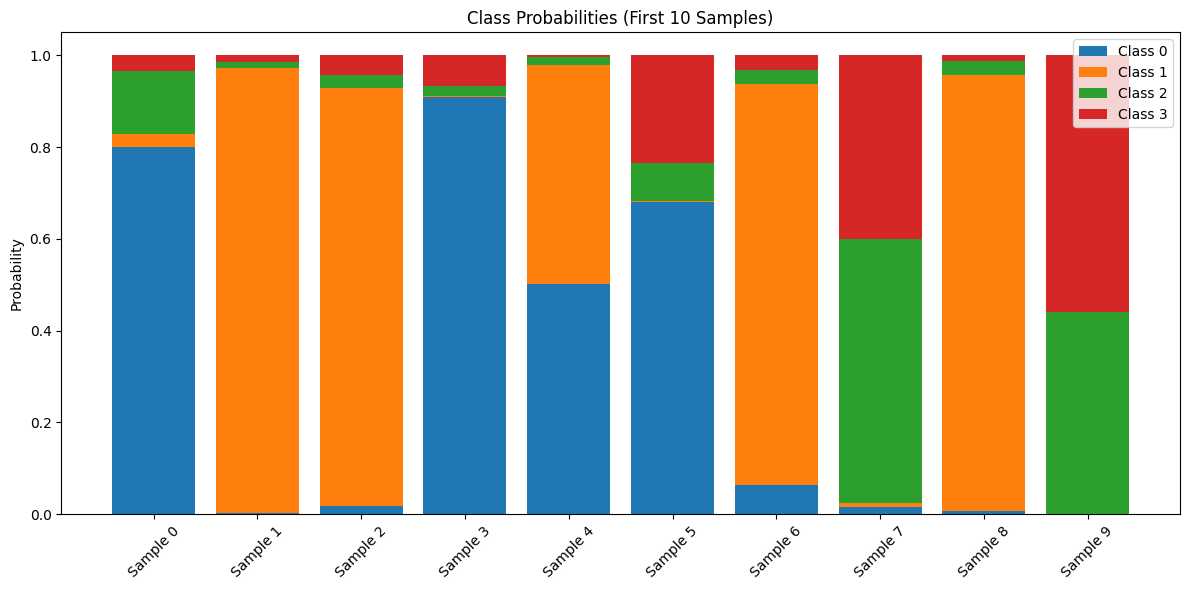

In [19]:
#########################################################################################################

# load optimal weights
model.load_weights('/tmp/checkpoint.h5')

#predict
print(model.summary())
probs = model.predict(X_test)

k=1 # If k is 1, just accept all highest probs (preds       = probs.argmax(axis = -1)  )
# k >= 1

preds, Y_test_eegnet, mask = accept_confident_probabilities(probs, k, Y_test)
omitted = X_test[~mask]

acc = np.mean(preds == Y_test_eegnet.argmax(axis=-1))
print("Classification accuracy EEGNet: %f " % (acc))
print(len(omitted), " samples deleted")

############################# xDAWN + RG Portion ##############################

# code is taken from PyRiemann's ERP sample script, which is decoding in 
# the tangent space with a logistic regression

n_components = 2  # pick some components

# set up sklearn pipeline
clf = make_pipeline(XdawnCovariances(n_components),
                    TangentSpace(metric='riemann'),
                    LogisticRegression())

preds_rg     = np.zeros(len(Y_test))

# reshape back to (trials, channels, samples)
X_train_reshaped      = X_train.reshape(X_train.shape[0], chans, samples)
X_test_reshaped       = X_test.reshape(X_test.shape[0], chans, samples)

# train a classifier with xDAWN spatial filtering + Riemannian Geometry (RG)
# labels need to be back in single-column format
clf.fit(X_train_reshaped, Y_train.argmax(axis = -1))
preds_rg     = clf.predict(X_test_reshaped)

# Printing the results
acc2         = np.mean(preds_rg == Y_test.argmax(axis = -1))
print("Classification accuracy xDAWN + RG: %f " % (acc2))

# plot the confusion matrices for both classifiers

plt.figure(0)
plot_confusion_matrix(preds, Y_test_eegnet.argmax(axis = -1), names, title = 'EEGNet-8,2')


plt.figure(1)
plot_confusion_matrix(preds_rg, Y_test.argmax(axis = -1), names, title = 'xDAWN + RG')

plt.show()

# Show only the first 10 samples for clarity
samples_to_plot = 10
util.plot_predicted_probs(probs, samples_to_plot)
